### Importing data

In [81]:
import os
os.getcwd()
new_directory = 'c:\\Users\\Alex\\Documents\\repos\\Predicting ATP Tennis Match Outcomes\\tennis_atp'

# Change the working directory
os.chdir(new_directory)
os.getcwd()


'c:\\Users\\Alex\\Documents\\repos\\Predicting ATP Tennis Match Outcomes\\tennis_atp'

In [69]:
import pandas as pd
#pd.set_option('display.max_columns', None)
# Read the CSV files for 2017-2023
atp_matches_2017 = pd.read_csv("atp_matches_2017.csv", sep=",")
atp_matches_2018 = pd.read_csv("atp_matches_2018.csv", sep=",")
atp_matches_2019 = pd.read_csv("atp_matches_2019.csv", sep=",")
atp_matches_2020 = pd.read_csv("atp_matches_2020.csv", sep=",")
atp_matches_2021 = pd.read_csv("atp_matches_2021.csv", sep=",")
atp_matches_2022 = pd.read_csv("atp_matches_2022.csv", sep=",")
atp_matches_2023 = pd.read_csv("atp_matches_2023.csv", sep=",")

# Concatenate the dataframes and sort columns
atp_matches = pd.concat([atp_matches_2017,atp_matches_2018,atp_matches_2019,atp_matches_2020,atp_matches_2021, atp_matches_2022, atp_matches_2023], ignore_index=True)
sorted_columns = sorted(atp_matches.columns, key=lambda x: (x.split('_')[-1], x))
atp_matches = atp_matches[sorted_columns]
atp_matches

FileNotFoundError: [Errno 2] No such file or directory: 'atp_matches_2017.csv'

### Data types

In [27]:
pd.DataFrame(atp_matches.dtypes,columns=["Type"])

,Type
l_1stIn,float64
w_1stIn,float64
l_1stWon,float64
w_1stWon,float64
l_2ndWon,float64
w_2ndWon,float64
l_SvGms,float64
w_SvGms,float64
l_ace,float64
w_ace,float64


### Definition of main player

In [28]:
# Main player definition and missing value imputation
# Constructing win indicator
import numpy as np

np.random.seed(42)
atp_matches['Main_player'] = np.where(np.random.binomial(n=1, p=0.5, size=len(atp_matches)) == 1, 'winner', 'loser')
atp_matches['Outcome'] = np.where(atp_matches['Main_player'] == 'winner', 1, 0)
atp_matches['Main_player_name'] = np.where(atp_matches['Main_player'] == 'winner', atp_matches['winner_name'],
                                           atp_matches['loser_name'])
atp_matches['Other_player_name'] = np.where(atp_matches['Main_player'] == 'winner', atp_matches['loser_name'],
                                           atp_matches['winner_name'])

### Variable transformations of raw variables

Calculate difference in age, rank and height of main player and other player

In [29]:

atp_matches['age_diff'] = atp_matches.apply(
    lambda row: row['winner_age'] - row['loser_age'] if row['Main_player'] == 'winner' else row['loser_age'] - row[
        'winner_age'], axis=1)

atp_matches['rank_diff'] = atp_matches.apply(
    lambda row: row['winner_rank'] - row['loser_rank'] if row['Main_player'] == 'winner' else row['loser_rank'] - row[
        'winner_rank'], axis=1)

atp_matches['height_diff'] = atp_matches.apply(
    lambda row: row['winner_ht'] - row['loser_ht'] if row['Main_player'] == 'winner' else row['loser_ht'] - row[
        'winner_ht'], axis=1)

## Construction of Player  database

In order to calculate evolution of match statistics for each main player and other player, we need to able to introduce a measure of time. Since only the start date of the tournament is given, we need to introduce a measure, which can sort the matches chonologically. To do so we can use the round of the match and convert to numerical as follows:
    

In [30]:
atp_matches[atp_matches['round']=='RR']['tourney_name']

266       Davis Cup G1 R1: DOM vs CHI
267       Davis Cup G1 R1: DOM vs CHI
268       Davis Cup G1 R1: DOM vs CHI
269       Davis Cup G1 R1: DOM vs CHI
270       Davis Cup G1 R1: ISR vs POR
                     ...             
18707    Davis Cup WG2 PO: RSA vs LUX
18708    Davis Cup WG2 PO: TUN vs CYP
18709    Davis Cup WG2 PO: TUN vs CYP
18710    Davis Cup WG2 PO: TUN vs CYP
18711    Davis Cup WG2 PO: TUN vs CYP
Name: tourney_name, Length: 1709, dtype: object

Round robin matches are mathes, where each player competes against each other (e.g in a Davis-Cup or Nitto ATP Finals). Since we cannot order such matches based on the data available, we exclude all round robin matches.



In [31]:

# Define the round mapping dictionary
round_mapping = {
    'RR': -1,
    'BR': 0,
    'R128': 1,
    'R64': 2,
    'R32': 3,
    'R16': 4,
    'QF': 5,
    'SF': 6,
    'F': 7
}

# Convert the 'round' column to integers based on the mapping
atp_matches['round'] = atp_matches['round'].map(round_mapping)

# Handle unmapped values by setting them to a default value (e.g., 0)
atp_matches['round'] = atp_matches['round'].fillna(0)

# Remove matches, where round<=0
atp_matches = atp_matches[atp_matches['round']>0]

Now de define a dataset, which lists every match a specific player has played. This data is player-specific, and will be used to calculate time evolution player statistics. We then sort the player database by increasing tournament date and increasing round such that data is ordered chronologically.

In [32]:
import warnings
warnings.filterwarnings('ignore')
all_matches_per_player = []
players = atp_matches["Main_player_name"].drop_duplicates()
for player_name in players:
    player_matches = atp_matches[(atp_matches["loser_name"]==player_name) | (atp_matches["winner_name"]==player_name)]
    player_matches["player"] = player_name
    player_matches.drop('Main_player_name', axis=1, inplace=True)
    all_matches_per_player.append(player_matches)


all_matches_per_player = pd.concat(all_matches_per_player, ignore_index=True)
all_matches_per_player = all_matches_per_player.sort_values(by=['player', 'tourney_date','round']
                                                            , ascending=[True, True,True])
##

We redefine the outcome variable in the player database such that it is player-specific and not Main_player-specific

In [33]:
all_matches_per_player["player_outcome"] = all_matches_per_player.apply(lambda row: 1 if row['player']==row['winner_name']
                                                                        else 0, axis=1).astype(int)


## Construction of historical Win-Loss Ratio 

We now define the historical Win-Loss ratio based on the previous 10 matches. This is believed to be highly correlated with the outcome of the match and therefore also is expected to bear a high predictive strength when commencing upon modelling. 

In [34]:
all_matches_per_player['shifted_outcome'] = all_matches_per_player.groupby('player')['player_outcome'].shift(1)
Rolling_wins = all_matches_per_player.groupby('player')['shifted_outcome'].rolling(window=10,min_periods=1).sum().reset_index(level=0, drop=True)
all_matches_per_player['shifted_matches'] = all_matches_per_player['shifted_outcome'].notna()
Rolling_matches = all_matches_per_player.groupby('player')['shifted_matches'].rolling(window=10,min_periods=1).sum().reset_index(level=0, drop=True)

# Calculate rolling win-loss ratio and adding match number
all_matches_per_player['Rolling_WLR'] = Rolling_wins / Rolling_matches
all_matches_per_player['Match_number'] = all_matches_per_player.groupby('player').cumcount() + 1


## Construction of historical First Serve Percentage

Define total number of service points and total number of 1st serves in for each player in player database

In [35]:

all_matches_per_player['svpt'] = all_matches_per_player.apply( lambda row: row['w_svpt'] if row['player'] == row['winner_name']
                                                              else  row['l_svpt'], axis=1)

all_matches_per_player['svIn'] = all_matches_per_player.apply( lambda row: row['w_1stIn'] if row['player'] == row['winner_name']
                                                              else  row['l_1stIn'],axis=1)

all_matches_per_player['shifted_svpt'] = all_matches_per_player.groupby('player')['svpt'].shift(1)
all_matches_per_player['shifted_svIn'] = all_matches_per_player.groupby('player')['svIn'].shift(1)


Calculate historical First Serve Percentage based on last 10 matches

In [36]:


all_matches_per_player['Rolling_SVP'] = (all_matches_per_player.groupby('player')['shifted_svIn'].rolling(window=10,
                                                                                          min_periods=1).sum().reset_index(
    level=0, drop=True) /
                             all_matches_per_player.groupby('player')['shifted_svpt'].rolling(window=10,
                                                                                          min_periods=1).sum().reset_index(
                                 level=0, drop=True))

## Construction of historical Break Points Saved Percentage

In [37]:

all_matches_per_player['bpFaced'] = all_matches_per_player.apply( lambda row: row['w_bpFaced'] if row['player'] == row['winner_name']
                                                              else  row['l_bpFaced'], axis=1)

all_matches_per_player['bpSaved'] = all_matches_per_player.apply( lambda row: row['w_bpSaved'] if row['player'] == row['winner_name']
                                                              else  row['l_bpSaved'],axis=1)

all_matches_per_player['shifted_bpFaced'] = all_matches_per_player.groupby('player')['bpFaced'].shift(1)
all_matches_per_player['shifted_bpSaved'] = all_matches_per_player.groupby('player')['bpSaved'].shift(1)

In [38]:
all_matches_per_player['Rolling_BPS'] = (all_matches_per_player.groupby('player')['shifted_bpSaved'].rolling(window=10,
                                                                                          min_periods=1).sum().reset_index(
    level=0, drop=True) /
                             all_matches_per_player.groupby('player')['shifted_bpFaced'].rolling(window=10,
                                                                                          min_periods=1).sum().reset_index(
                                 level=0, drop=True))

We can for example visualize the performance over time of each individual player, based on the Win-loss ratio, as follows:



In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def evolution(x,y,data, player, t=False):
    # Filter data for the specified player
    df = data[data['Main_player_name'] == player]

    # Plot the scatter points
    sns.scatterplot(x=x, y=y, data=df)

    # Add a loess smoother (regression line)
    sns.regplot(x=x, y=y, data=df, scatter=False, label='Loess Smoother', lowess=True, line_kws={'color': 'red'})


    plt.xlabel(f'{x}')
    plt.ylabel(f'{y}')
    plt.title(f'Evolution of historical {y.split("_")[-1]} for {player}')

    # Show the plot
    plt.show()

    # Optionally, print the first 30 rows if t is True
    if t:
        return pd.DataFrame(df).head(50)


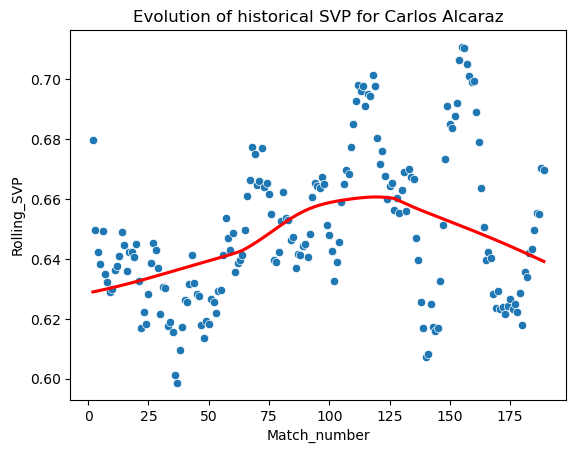

In [41]:
all_matches_per_player.rename(columns={'player': 'Main_player_name'}, inplace=True)
evolution(data = all_matches_per_player, player = 'Carlos Alcaraz',x='Match_number',y='Rolling_SVP')

In [85]:
cols = ['match_num','Match_number','tourney_date','Main_player_name','Rolling_WLR','Rolling_SVP','Rolling_BPS']
evolution_statistics = all_matches_per_player[cols]

## Merging player evolution statistics onto atp_matches data

In [87]:
pd.set_option('display.max_columns', None)
ev_stat = evolution_statistics.copy()
test = pd.merge(atp_matches,ev_stat,how="left",on = ["match_num","Main_player_name","tourney_date"])
test = test.sort_values(by=['Main_player_name', 'tourney_date','round']
                                                           , ascending=[True, True,True])
ev_stat.rename(columns={'Main_player_name': 'Other_player_name'}, inplace=True)
test2 = pd.merge(test,ev_stat,how="left",on = ["match_num","Other_player_name","tourney_date"])


test2["Rolling_WLR_diff"]=test2["Rolling_WLR_x"]-test2["Rolling_WLR_y"]
test2["Rolling_SVP_diff"]=test2["Rolling_SVP_x"]-test2["Rolling_SVP_y"]
test2["Rolling_BPS_diff"]=test2["Rolling_BPS_x"]-test2["Rolling_BPS_y"]
test2.sort_values(by=['Main_player_name', 'tourney_date','round']
                                                           , ascending=[True, True,True])


,l_1stIn,w_1stIn,l_1stWon,w_1stWon,l_2ndWon,w_2ndWon,l_SvGms,w_SvGms,l_ace,w_ace,loser_age,winner_age,l_bpFaced,w_bpFaced,l_bpSaved,w_bpSaved,tourney_date,l_df,w_df,loser_entry,winner_entry,loser_hand,winner_hand,loser_ht,winner_ht,loser_id,tourney_id,winner_id,loser_ioc,winner_ioc,tourney_level,minutes,loser_name,tourney_name,winner_name,match_num,best_of,loser_rank_points,winner_rank_points,loser_rank,winner_rank,round,score,loser_seed,winner_seed,draw_size,surface,l_svpt,w_svpt,Main_player,Outcome,Main_player_name,Other_player_name,age_diff,rank_diff,height_diff,Match_number_x,Rolling_WLR_x,Rolling_SVP_x,Rolling_BPS_x,Match_number_y,Rolling_WLR_y,Rolling_SVP_y,Rolling_BPS_y,Rolling_WLR_diff,Rolling_SVP_diff,Rolling_BPS_diff
0,38.0,33.0,18.0,24.0,9.0,8.0,10.0,9.0,0.0,3.0,27.0,19.4,11.0,7.0,4.0,4.0,20230417,0.0,2.0,Q,Q,R,L,183.0,NaN,111200,2023-2841,209406,SWE,JOR,A,91.0,Elias Ymer,Banja Luka,Abedallah Shelbayh,280,3,419.0,201.0,139.0,267.0,3,6-1 7-5,NaN,NaN,32,Clay,63.0,55.0,winner,1,Abedallah Shelbayh,Elias Ymer,-7.6,128.0,NaN,2,0.000000,0.574713,0.700000,54.0,0.400000,0.557760,0.632184,-0.400000,0.016953,0.067816
1,46.0,41.0,29.0,27.0,19.0,15.0,11.0,11.0,2.0,1.0,19.4,23.6,10.0,4.0,5.0,0.0,20230417,8.0,0.0,Q,NaN,L,R,NaN,183.0,209406,2023-2841,200175,JOR,SRB,A,124.0,Abedallah Shelbayh,Banja Luka,Miomir Kecmanovic,291,3,201.0,1125.0,267.0,33.0,4,6-4 7-6(4),NaN,4.0,32,Clay,95.0,70.0,loser,0,Abedallah Shelbayh,Miomir Kecmanovic,-4.2,234.0,NaN,3,0.500000,0.584507,0.647059,196.0,0.500000,0.618541,0.649123,0.000000,-0.034034,-0.002064
2,36.0,34.0,23.0,24.0,10.0,17.0,8.0,9.0,3.0,3.0,19.4,28.0,9.0,2.0,6.0,2.0,20230424,4.0,3.0,WC,NaN,L,R,NaN,185.0,209406,2023-1536,106398,JOR,ARG,M,83.0,Abedallah Shelbayh,Madrid Masters,Pedro Cachin,200,3,233.0,767.0,243.0,67.0,1,6-1 6-4,NaN,NaN,128,Clay,62.0,59.0,loser,0,Abedallah Shelbayh,Pedro Cachin,-8.6,176.0,NaN,4,0.333333,0.544304,0.592593,33.0,0.300000,0.609831,0.500000,0.033333,-0.065527,0.092593
3,28.0,33.0,15.0,25.0,9.0,12.0,8.0,9.0,3.0,4.0,19.6,25.8,7.0,2.0,3.0,1.0,20230626,4.0,3.0,Q,Q,L,R,NaN,185.0,209406,2023-8994,126128,JOR,RUS,A,74.0,Abedallah Shelbayh,Mallorca,Roman Safiullin,272,3,238.0,631.0,240.0,94.0,3,6-1 6-4,NaN,NaN,32,Grass,49.0,56.0,loser,0,Abedallah Shelbayh,Roman Safiullin,-6.2,146.0,NaN,5,0.250000,0.551839,0.611111,37.0,0.400000,0.660615,0.575758,-0.150000,-0.108775,0.035354
4,43.0,40.0,32.0,32.0,11.0,14.0,10.0,11.0,3.0,10.0,19.9,28.4,6.0,3.0,4.0,3.0,20231106,5.0,1.0,Q,NaN,L,R,NaN,191.0,209406,2023-0341,132283,JOR,ITA,A,93.0,Abedallah Shelbayh,Metz,Lorenzo Sonego,292,3,294.0,955.0,215.0,49.0,4,6-3 7-5,NaN,6.0,32,Hard,70.0,60.0,loser,0,Abedallah Shelbayh,Lorenzo Sonego,-8.5,166.0,NaN,8,0.285714,0.560484,0.606557,237.0,0.500000,0.637066,0.636364,-0.214286,-0.076582,-0.029806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16995,35.0,22.0,25.0,16.0,8.0,6.0,6.0,7.0,2.0,2.0,23.2,30.5,6.0,3.0,6.0,1.0,20220919,2.0,1.0,Q,NaN,R,R,185.0,185.0,200267,2022-0341,105932,BEL,GEO,A,68.0,Zizou Bergs,Metz,Nikoloz Basilashvili,273,3,411.0,1210.0,134.0,36.0,3,4-6 1-2 RET,NaN,5.0,32,Hard,54.0,36.0,loser,0,Zizou Bergs,Nikoloz Basilashvili,-7.3,98.0,0.0,8,0.285714,0.664360,0.629630,266.0,0.300000,0.568019,0.539326,-0.014286,0.096341,0.090304
16996,65.0,58.0,47.0,39.0,14.0,24.0,17.0,17.0,7.0,7.0,23.6,27.6,13.0,9.0,7.0,5.0,20230116,5.0,1.0,Q,NaN,R,R,185.0,188.0,200267,2023-580,111513,BEL,SRB,G,158.0,Zizou Bergs,Australian Open,Laslo Djere,145,5,428.0,758.0,130.0,68.0,1,6-4 1-6 6-4 6-1,NaN,NaN,128,Hard,107.0,102.0,loser,0,Zizou Bergs,Laslo Djere,-4.0,62.0,-3.0,9,0.250000,0.662975,0.666667,202.0,0.400000,0.627273,0.656250,-0.150000,0.035702,0.010417
16997,78.0,51.0,53.0,35.0,14.0,19.0,16.0,15.0,8.0,3.0,24.1,23.8,16.0,11.0,11.0,7.0,20230717,9.0,3.0,Q,NaN,R,R,185.0,183.0,200267,2023

In [44]:
## Including main_player_labels to ease use in 'Data for predictions' file

test2['Main_player_age'] = np.where(test2['Main_player'] == 'winner', test2['winner_age'],
                                    test2['loser_age'])
test2['Main_player_height'] = np.where(test2['Main_player'] == 'winner', test2['winner_ht'],
                                    test2['loser_ht'])
test2['Main_player_rank'] = np.where(test2['Main_player'] == 'winner', test2['winner_rank'],
                                    test2['loser_rank'])


## Splitting data into train and test

In [45]:
from sklearn.model_selection import train_test_split
X = test2.copy()
X.drop('Outcome',axis=1, inplace=True)
y = test2['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Saving for further use

In [88]:
current_directory = os.getcwd()
current_directory
#parent_directory = os.path.dirname(current_directory)
#print(current_directory,parent_directory)

# Change the working directory to the parent directory
new_directory = '..\\Python\\Temp data'

# Change the working directory
os.chdir(new_directory)
#os.getcwd()

FileNotFoundError: [WinError 3] Den angivne sti blev ikke fundet: '..\\Python\\Temp data'

In [84]:
X_train.to_csv('X_train.csv', index=False)  # Set index=False to exclude the index column
X_test.to_csv('X_test.csv', index=False)  # Set index=False to exclude the index column
y_train.to_csv('y_train.csv', index=False)  # Set index=False to exclude the index column
y_test.to_csv('y_test.csv', index=False)  # Set index=False to exclude the index column